In [98]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df_video = pd.read_csv(r"D:\tn-da22tta-110122034-chaugiabao-youtube-dw-trending\src\analysis\data\cleaned_video.csv")
pd.set_option('display.max_columns', None)
print(f"Data shape before: {df_video.shape}")
print(f"Unique video_id before: {df_video['video_id'].nunique()}")

Data shape before: (1171067, 45)
Unique video_id before: 158068


In [99]:
# Chuyển snapshot_time về datetime
df_video["snapshot_time"] = pd.to_datetime(
    df_video["snapshot_time"],
    errors="coerce"
)

# Giữ snapshot đầu tiên của mỗi video
df_unique = (
    df_video
    .sort_values("snapshot_time")
    .drop_duplicates("video_id", keep="first")
    .copy()
)

print(f"Data shape after: {df_unique.shape}")
print(f"Unique video_id after: {df_unique['video_id'].nunique()}")

Data shape after: (158068, 45)
Unique video_id after: 158068


In [100]:
# Sử dụng tập unique video cho EDA mô tả

df_video = df_unique.copy()

print(df_video.shape)

(158068, 45)


In [101]:
print(df_video.columns.tolist())


['video_id', 'views', 'likes', 'comments', 'snapshot_time', 'is_trending', 'channel_id', 'time_id', 'source', 'title', 'description', 'publish_time', 'thumbnail', 'keyword', 'topic', 'duration_seconds', 'definition', 'caption', 'licensed_content', 'category_id', 'default_language', 'default_audio_language', 'tags', 'channel_title', 'custom_url', 'channel_description', 'channel_created_at', 'country', 'subscriber_count', 'view_count', 'video_count', 'date', 'year', 'quarter', 'month', 'week_of_year', 'day', 'weekday', 'hour', 'country_region', 'like_rate', 'comment_rate', 'publish_weekday', 'publish_hour', 'snapshot_weekday']


In [102]:
print(df_video.dtypes)

video_id                               object
views                                   int64
likes                                   int64
comments                                int64
snapshot_time             datetime64[ns, UTC]
is_trending                              bool
channel_id                             object
time_id                                 int64
source                                 object
title                                  object
description                            object
publish_time                           object
thumbnail                              object
keyword                                object
topic                                  object
duration_seconds                        int64
definition                             object
caption                                  bool
licensed_content                         bool
category_id                             int64
default_language                       object
default_audio_language            

In [103]:
df_comment = pd.read_csv(r"D:\tn-da22tta-110122034-chaugiabao-youtube-dw-trending\src\analysis\data\comments_dataset_final.csv")
pd.set_option('display.max_columns', None)
print(f"Data shape: {df_comment.shape}")
df_comment.head()

Data shape: (7349440, 7)


,comment_id,video_id,comment_text,like_count,published_at,sentiment_label,sentiment_score
0,Ugz4G-vGa83OlwFyQbF4AaABAg,-83WCkzLmxQ,Hi gongsam saya dari Malaysia 🎉🎉,2,2025-12-23 20:08:17,positive,0.508761
1,Ugy7HIewolJ5SBYQhw14AaABAg,-83WCkzLmxQ,You are living the best life! =D and I want a ...,0,2026-02-17 10:03:20,positive,0.914869
2,UgwPkg66IyMxThiCBEp4AaABAg,-83WCkzLmxQ,I really need to learn how to eat because thes...,0,2025-12-30 08:07:10,positive,0.618799
3,Ugy8i3QITCPrWjhCdDl4AaABAg,-83WCkzLmxQ,I love youuu gongsam❤❤😊,0,2025-12-24 15:18:32,positive,0.879206
4,UgxBMMOqU7fifDeJagd4AaABAg,-83WCkzLmxQ,You will always make our mouth watere,1,2026-04-12 21:51:43,positive,0.384686


## Phân tích tổng quan dữ liệu

In [104]:
df_video.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158068 entries, 0 to 1171066
Data columns (total 45 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   video_id                158068 non-null  object             
 1   views                   158068 non-null  int64              
 2   likes                   158068 non-null  int64              
 3   comments                158068 non-null  int64              
 4   snapshot_time           158068 non-null  datetime64[ns, UTC]
 5   is_trending             158068 non-null  bool               
 6   channel_id              158068 non-null  object             
 7   time_id                 158068 non-null  int64              
 8   source                  158068 non-null  object             
 9   title                   158068 non-null  object             
 10  description             158068 non-null  object             
 11  publish_time            158068

In [105]:
df_video['video_id'].nunique()

158068

In [106]:
df_video['channel_id'].nunique()

83173

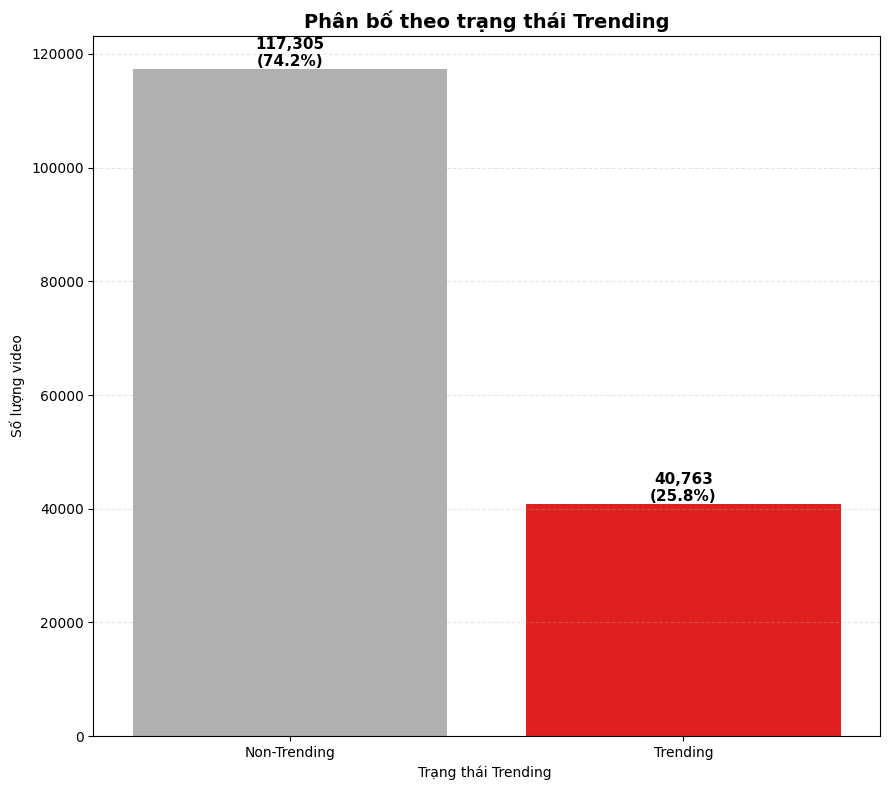

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,8))

palette = {
    0: "#B0B0B0",
    1: "#FF0000"
}

ax = sns.countplot(
    x="is_trending",
    data=df_video,
    hue="is_trending",
    palette=palette,
    legend=False
)

total = len(df_video)

for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100

    ax.annotate(
        f"{count:,}\n({pct:.1f}%)",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Phân bố theo trạng thái Trending",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Trạng thái Trending ")
plt.ylabel("Số lượng video")
plt.xticks([0,1], ["Non-Trending", "Trending"])

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [108]:
df_video['topic'].value_counts()

topic
gaming           50224
music            24313
entertainment    20771
education        12002
vlog              8570
food              7164
fitness           6236
sports            5413
technology        3850
beauty            3553
travel            3262
people            2852
motivation        2227
animals           2167
finance           2090
kids              1457
business          1244
film               382
comedy             122
science             51
news                43
cars                29
howto               26
nonprofit           11
pets                 9
Name: count, dtype: int64

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22768\2649068305.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


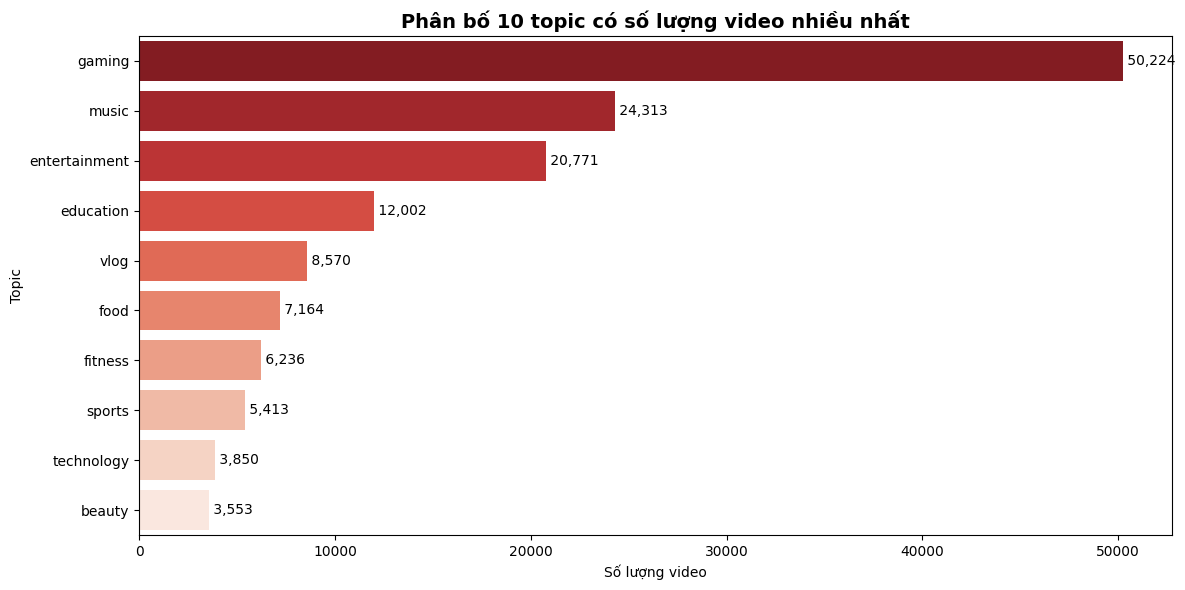

In [109]:
topic_counts = (
    df_video
    .groupby("topic")["video_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="Count")
)

topic_counts.columns = ["Topics", "Count"]

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=topic_counts,
    x="Count",
    y="Topics",
    palette="Reds_r"
)

for i, v in enumerate(topic_counts["Count"]):
    ax.text(
        v,
        i,
        f" {v:,}",
        va="center",
        fontsize=10
    )

plt.title(
    "Phân bố 10 topic có số lượng video nhiều nhất",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Số lượng video")
plt.ylabel("Topic")

plt.tight_layout()
plt.show()

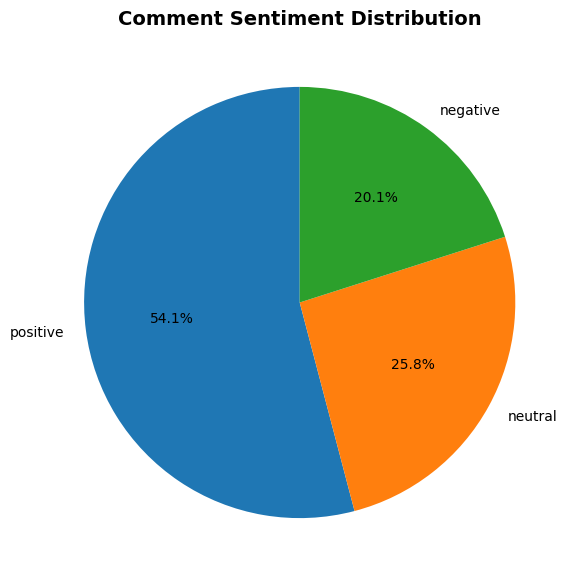

In [110]:
sentiment_counts = df_comment["sentiment_label"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Comment Sentiment Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.show()

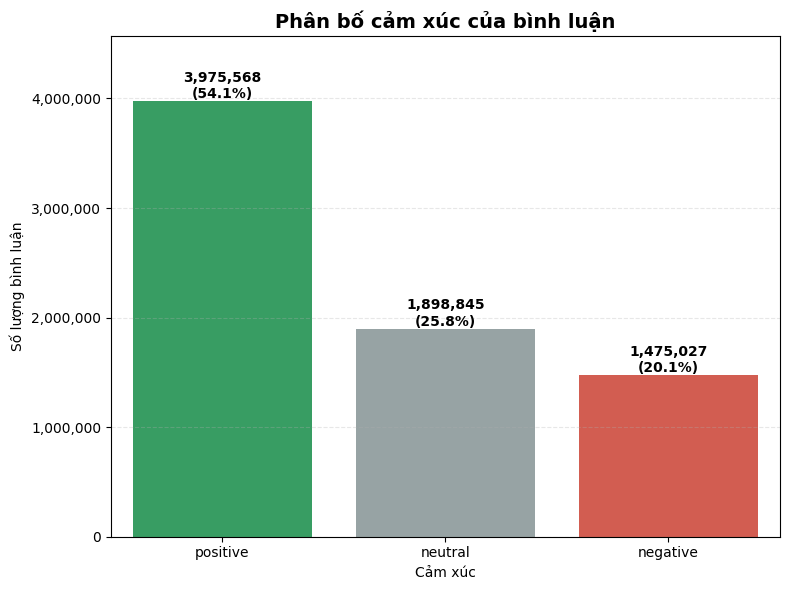

In [111]:
import matplotlib.ticker as mtick
plt.figure(figsize=(8,6))

sentiment_counts = (
    df_comment["sentiment_label"]
    .value_counts()
    .reset_index()
)

sentiment_counts.columns = ["Sentiment", "Count"]

palette = {
    "negative": "#E74C3C",
    "neutral": "#95A5A6",
    "positive": "#27AE60"
}

ax = sns.barplot(
    data=sentiment_counts,
    x="Sentiment",
    y="Count",
    hue="Sentiment",
    palette=palette,
    legend=False
)

# Hiển thị dấu phẩy thay vì 1e6
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, p: f"{int(x):,}")
)

total = sentiment_counts["Count"].sum()

for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100

    ax.annotate(
        f"{count:,}\n({pct:.1f}%)",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Tăng khoảng trống phía trên
ax.set_ylim(0, sentiment_counts["Count"].max() * 1.15)

plt.title(
    "Phân bố cảm xúc của bình luận",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Cảm xúc")
plt.ylabel("Số lượng bình luận")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

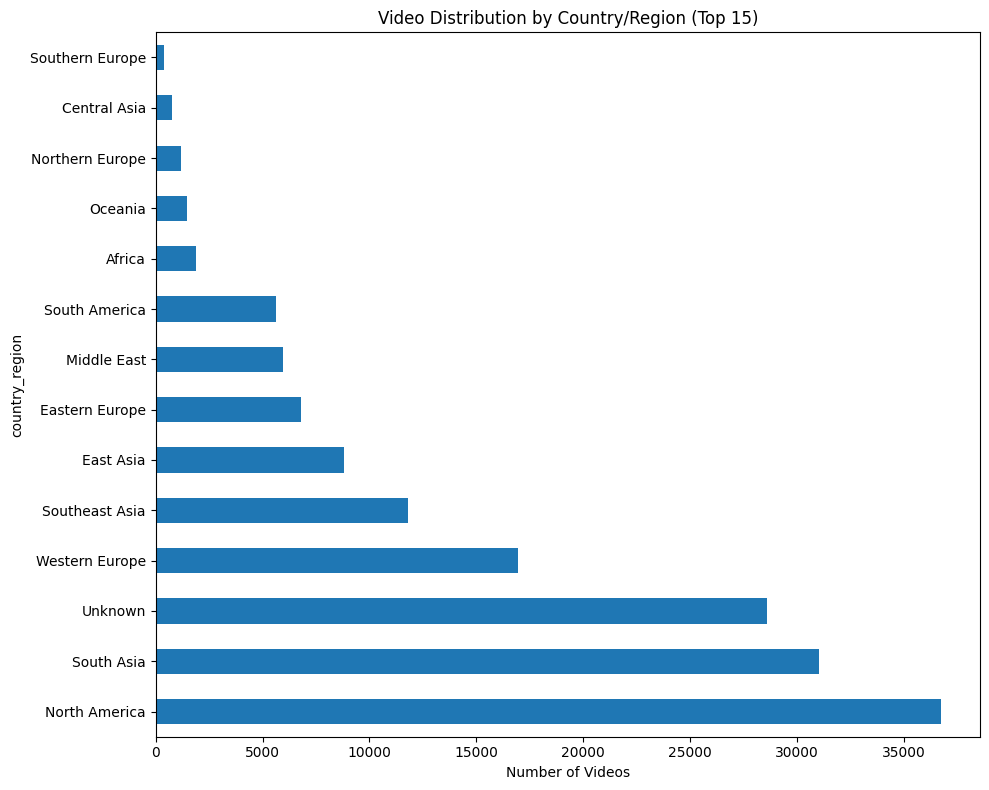

country_region
North America      36741
South Asia         31024
Unknown            28633
Western Europe     16950
Southeast Asia     11792
East Asia           8801
Eastern Europe      6799
Middle East         5973
South America       5641
Africa              1883
Oceania             1482
Northern Europe     1169
Central Asia         774
Southern Europe      406
Name: count, dtype: int64


In [112]:
# Top 15 by count
country_dist = df_video[['video_id','country_region']].drop_duplicates()['country_region'].value_counts().head(15)

country_dist.plot(kind='barh', figsize=(10, 8))
plt.title('Video Distribution by Country/Region (Top 15)')
plt.xlabel('Number of Videos')
plt.tight_layout()
plt.show()

print(country_dist)

## Phân tích đặc trưng tương tác

In [113]:
df_video["view_count"].describe()

count    1.580680e+05
mean     1.077759e+09
std      7.292175e+09
min      0.000000e+00
25%      1.243381e+06
50%      3.042229e+07
75%      2.998857e+08
max      3.422487e+11
Name: view_count, dtype: float64

In [114]:
df_video.groupby("is_trending")["view_count"].describe()

,count,mean,std,min,25%,50%,75%,max
is_trending,,,,,,,,
False,117305.0,1.190910e+09,7.647879e+09,0.0,512491.0,16420879.0,247557003.0,3.422487e+11
True,40763.0,7.521414e+08,6.143376e+09,0.0,13566271.0,88878004.0,405034329.0,3.422487e+11


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22768\3066434375.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


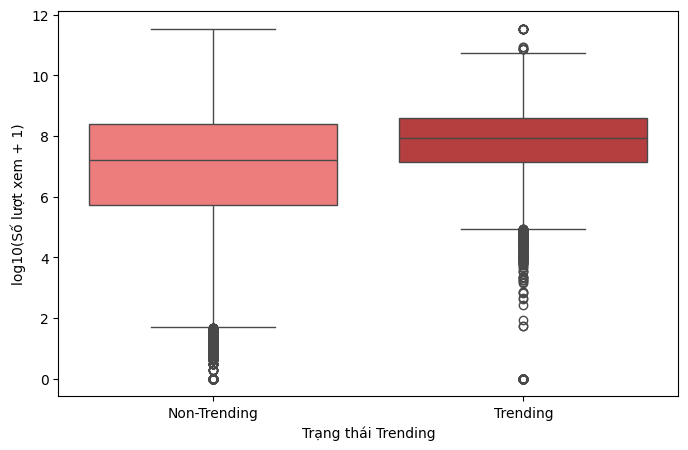

In [115]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_video,
    x="is_trending",
    y=np.log10(df_video["view_count"] + 1),
    palette=['#FF6B6B', '#C92A2A']  # Light red, Dark red
)

plt.xticks([0,1], ["Non-Trending", "Trending"])
plt.ylabel("log10(Số lượt xem + 1)")
plt.xlabel("Trạng thái Trending")

plt.show()

In [116]:
df_video.groupby("is_trending")["like_rate"].describe()

,count,mean,std,min,25%,50%,75%,max
is_trending,,,,,,,,
False,117305.0,0.028090,0.053550,0.0,0.007524,0.016706,0.032356,1.000000
True,40763.0,0.045826,0.042098,0.0,0.014763,0.034292,0.064749,0.914831


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22768\3585845886.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


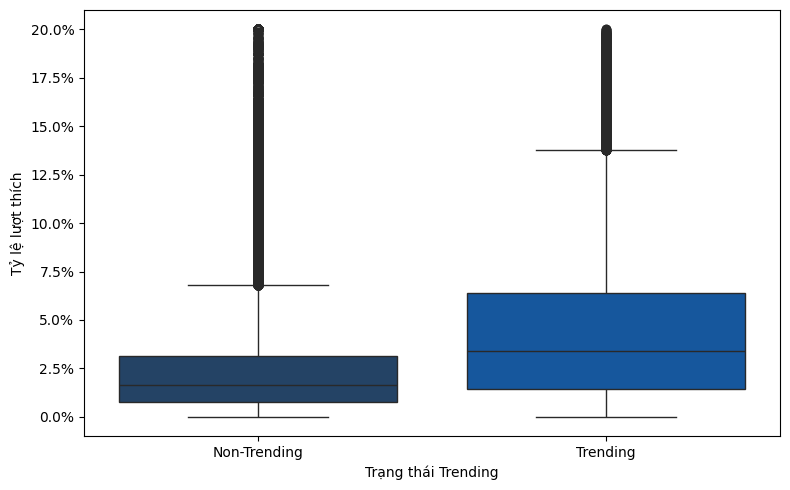

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# Loại bỏ 99th percentile
p99 = df_video["like_rate"].quantile(0.99)
df_plot = df_video[df_video["like_rate"] <= p99]

plt.figure(figsize=(8,5))

ax = sns.boxplot(
    data=df_plot,
    x="is_trending",
    y="like_rate",
    palette=["#194370", '#0056B3']
)

plt.xticks([0, 1], ["Non-Trending", "Trending"])
plt.ylabel("Tỷ lệ lượt thích")
plt.xlabel("Trạng thái Trending")

# Hiển thị trục Y dưới dạng %
ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=1)
)

plt.tight_layout()
plt.show()

In [118]:
df_video["comment_rate"].describe()

count    158068.000000
mean          0.003358
std           0.027078
min           0.000000
25%           0.000028
50%           0.000410
75%           0.001931
max           3.333333
Name: comment_rate, dtype: float64

In [119]:
df_video.groupby("is_trending")["comment_rate"].describe()

,count,mean,std,min,25%,50%,75%,max
is_trending,,,,,,,,
False,117305.0,0.003027,0.031042,0.0,0.000000,0.000239,0.001046,3.333333
True,40763.0,0.004309,0.008301,0.0,0.000407,0.002071,0.005121,0.379070


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22768\4236075571.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


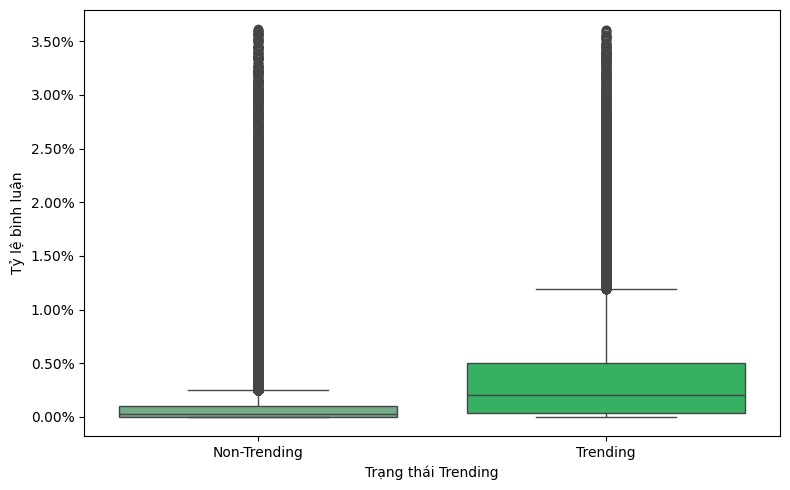

In [120]:
p99 = df_video["comment_rate"].quantile(0.99)
df_plot = df_video[df_video["comment_rate"] <= p99]

plt.figure(figsize=(8,5))

ax = sns.boxplot(
    data=df_plot,
    x="is_trending",
    y="comment_rate",
    palette=["#6BB486", '#22C55E']
)

plt.xticks([0,1], ["Non-Trending", "Trending"])
plt.ylabel("Tỷ lệ bình luận")
plt.xlabel("Trạng thái Trending")

# Hiển thị trục Y dưới dạng %
ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=1)
)

plt.tight_layout()
plt.show()

In [121]:
df_video = df_video[df_video['duration_seconds'] > 0]

In [122]:
(df_video["duration_seconds"] == 0).sum()

0

In [123]:
df_video["duration_seconds"].describe()

count    157981.000000
mean       1585.254505
std        5725.646370
min           1.000000
25%          34.000000
50%         159.000000
75%        1097.000000
max      416704.000000
Name: duration_seconds, dtype: float64

In [124]:
df_video.groupby("is_trending")["duration_seconds"].describe()

,count,mean,std,min,25%,50%,75%,max
is_trending,,,,,,,,
False,117218.0,1094.649516,5671.217393,1.0,25.0,58.0,538.0,416704.0
True,40763.0,2996.037215,5646.692691,2.0,368.0,1085.0,2295.0,59793.0


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22768\976285671.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


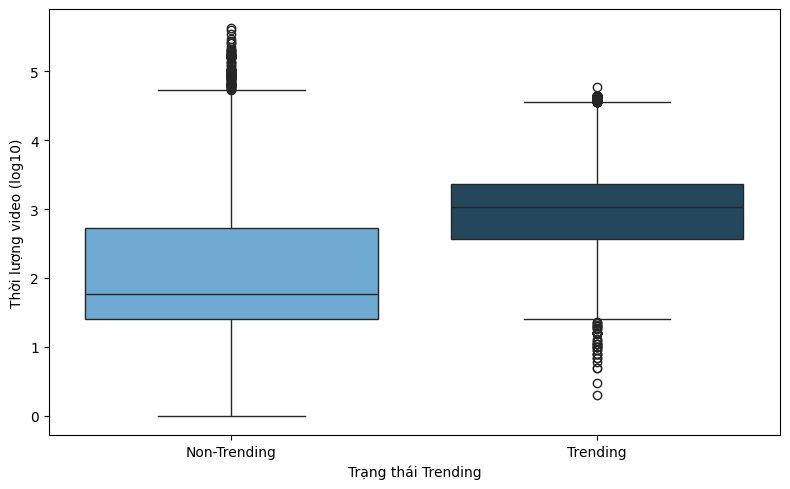

In [125]:
df_video["log_duration"] = np.log10(
    df_video["duration_seconds"]
)
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_video,
    x="is_trending",
    y="log_duration",
    palette=["#5DADE2", "#1B4965"] 
)

plt.xticks([0,1], ["Non-Trending", "Trending"])
plt.xlabel("Trạng thái Trending")
plt.ylabel("Thời lượng video (log10)")
plt.tight_layout()
plt.show()

In [126]:
df_video["subscriber_count"].describe()

count    1.579810e+05
mean     1.873444e+06
std      9.655540e+06
min      0.000000e+00
25%      3.120000e+03
50%      7.840000e+04
75%      7.540000e+05
max      4.900000e+08
Name: subscriber_count, dtype: float64

In [127]:
df_video.groupby("is_trending")["subscriber_count"].describe()

,count,mean,std,min,25%,50%,75%,max
is_trending,,,,,,,,
False,117218.0,2.032036e+06,1.051511e+07,0.0,1280.0,39600.0,633000.0,490000000.0
True,40763.0,1.417396e+06,6.564534e+06,0.0,43000.0,226000.0,968000.0,312000000.0


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22768\3449728180.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


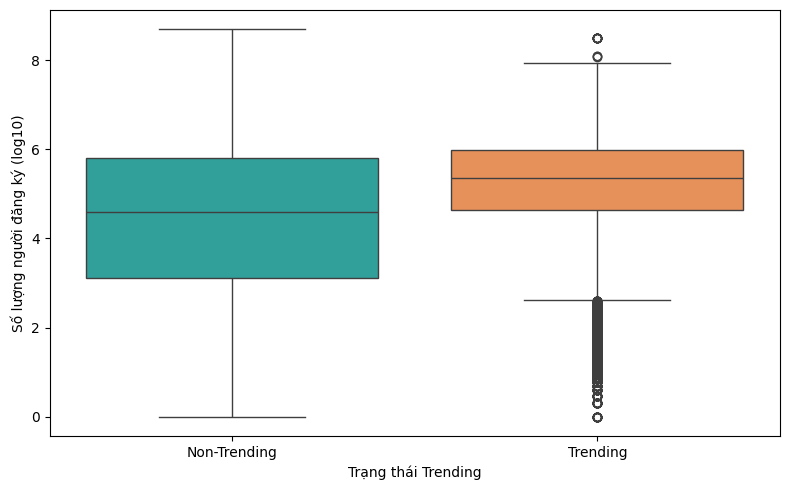

In [128]:
# Loại bỏ các kênh có subscriber = 0
df_subscriber = df_video[
    df_video["subscriber_count"] > 0
].copy()

# Log transform
df_subscriber["log_subscriber"] = np.log10(
    df_subscriber["subscriber_count"]
)

# Vẽ boxplot
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_subscriber,
    x="is_trending",
    y="log_subscriber",
    palette=["#20B2AA", "#FF8C42"]
)

plt.xticks([0, 1], ["Non-Trending", "Trending"])
plt.xlabel("Trạng thái Trending")
plt.ylabel("Số lượng người đăng ký (log10)")

plt.tight_layout()
plt.show()

In [129]:
# Đếm số lượng sentiment theo từng video
sentiment_features = (
    df_comment
    .groupby(['video_id', 'sentiment_label'])
    .size()
    .unstack(fill_value=0)
)

# Đảm bảo đủ 3 cột sentiment
for col in ['positive', 'neutral', 'negative']:
    if col not in sentiment_features.columns:
        sentiment_features[col] = 0

# Đổi tên cột
sentiment_features = sentiment_features.rename(columns={
    'positive': 'positive_count',
    'neutral': 'neutral_count',
    'negative': 'negative_count'
})

# Tổng comment
sentiment_features['total_comments'] = (
    sentiment_features['positive_count']
    + sentiment_features['neutral_count']
    + sentiment_features['negative_count']
)

# Ratio
sentiment_features['positive_ratio'] = (
    sentiment_features['positive_count']
    / sentiment_features['total_comments']
)

sentiment_features['neutral_ratio'] = (
    sentiment_features['neutral_count']
    / sentiment_features['total_comments']
)

sentiment_features['negative_ratio'] = (
    sentiment_features['negative_count']
    / sentiment_features['total_comments']
)

# Mean sentiment score của video
sentiment_features['avg_sentiment_score'] = (
    df_comment
    .groupby('video_id')['sentiment_score']
    .mean()
)

sentiment_features = sentiment_features.reset_index()

In [130]:
sentiment_features.shape

(124293, 9)

In [131]:
sentiment_features.head(5)

sentiment_label,video_id,negative_count,neutral_count,positive_count,total_comments,positive_ratio,neutral_ratio,negative_ratio,avg_sentiment_score
0,---k1vFBbWw,4,0,96,100,0.960000,0.000000,0.040000,0.875896
1,--0NZjUvuKs,41,25,34,100,0.340000,0.250000,0.410000,0.693600
2,--ASSQxzhPE,22,54,24,100,0.240000,0.540000,0.220000,0.577176
3,--Avak9eZ_0,3,6,83,92,0.902174,0.065217,0.032609,0.786855
4,--CKzGfPWn0,7,12,81,100,0.810000,0.120000,0.070000,0.771615


In [132]:
(
    sentiment_features['positive_ratio']
    + sentiment_features['neutral_ratio']
    + sentiment_features['negative_ratio']
).describe()

count    1.242930e+05
mean     1.000000e+00
std      2.755431e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

In [133]:
df_video_unique = (
    df_video
    .drop_duplicates(subset='video_id')
    .copy()
)

In [134]:
df_video_unique = df_video_unique.merge(
    sentiment_features,
    on='video_id',
    how='left'
)

In [135]:
print("df_video_unique:", df_video_unique.shape)
print("sentiment_features:", sentiment_features.shape)

df_video_unique: (157981, 54)
sentiment_features: (124293, 9)


In [136]:
sentiment_cols = [
    'positive_count',
    'neutral_count',
    'negative_count',
    'positive_ratio',
    'neutral_ratio',
    'negative_ratio',
    'avg_sentiment_score'
]

print(df_video_unique[sentiment_cols].isnull().sum())


positive_count         33727
neutral_count          33727
negative_count         33727
positive_ratio         33727
neutral_ratio          33727
negative_ratio         33727
avg_sentiment_score    33727
dtype: int64


In [137]:
df_video_unique = df_video_unique.dropna(subset=sentiment_cols)

print(f"Videos with sentiment: {len(df_video_unique)}")

Videos with sentiment: 124254


In [138]:
print(df_video_unique.groupby('is_trending')['avg_sentiment_score'].mean())

is_trending
False    0.677648
True     0.661199
Name: avg_sentiment_score, dtype: float64


In [139]:
sentiment_trending = (
    df_video_unique
    .groupby('is_trending')[
        [
            'positive_ratio',
            'neutral_ratio',
            'negative_ratio'
        ]
    ]
    .mean()
)

print(sentiment_trending)

             positive_ratio  neutral_ratio  negative_ratio
is_trending                                               
False              0.529185       0.270342        0.200472
True               0.475940       0.322773        0.201288


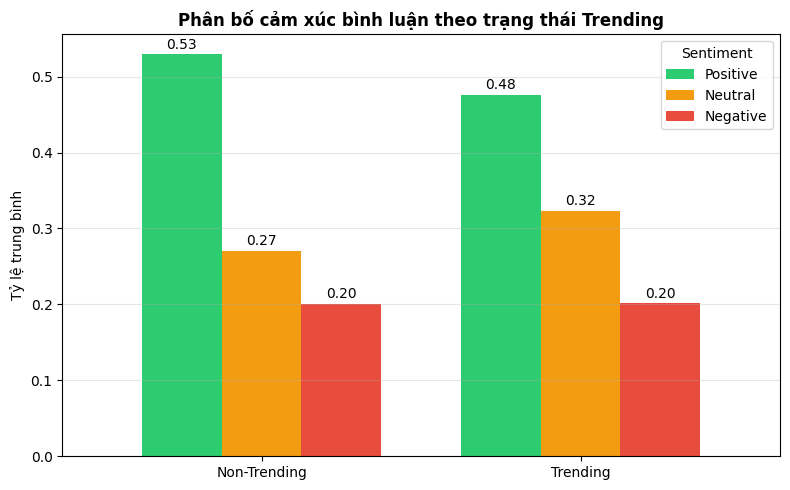

In [140]:
plot_data = sentiment_trending.copy()
plot_data.index = ['Non-Trending', 'Trending']

ax = plot_data.plot(
    kind='bar',
    figsize=(8, 5),
    width=0.75,
    color=['#2ECC71', '#F39C12', '#E74C3C']  # Green, Orange, Red
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2)

plt.title('Phân bố cảm xúc bình luận theo trạng thái Trending', fontsize=12, fontweight='bold')
plt.ylabel('Tỷ lệ trung bình')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(
    ['Positive', 'Neutral', 'Negative'],
    title='Sentiment'
)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [141]:
df_video_unique.head(5)

,video_id,views,likes,comments,snapshot_time,is_trending,channel_id,time_id,source,title,description,publish_time,thumbnail,keyword,topic,duration_seconds,definition,caption,licensed_content,category_id,default_language,default_audio_language,tags,channel_title,custom_url,channel_description,channel_created_at,country,subscriber_count,view_count,video_count,date,year,quarter,month,week_of_year,day,weekday,hour,country_region,like_rate,comment_rate,publish_weekday,publish_hour,snapshot_weekday,log_duration,negative_count,neutral_count,positive_count,total_comments,positive_ratio,neutral_ratio,negative_ratio,avg_sentiment_score
0,atJwRQ1zdjQ,350781,35288,2980,2026-05-13 06:46:25.134504+00:00,True,UCUs8sGiP4avNaYNVO22INhQ,2026051216,trending,mgk & Wiz Khalifa - girl next door (Official M...,Watch the official music video for mgk & @wizk...,2026-05-12 16:00:06+00:00,https://i.ytimg.com/vi/atJwRQ1zdjQ/default.jpg,trending,music,237,hd,False,False,10,en,Unknown,"mgk,wiz khalifa,girl next door,blog era boyz,b...",mgk,@mgk,Unknown,2006-12-27T05:10:50Z,US,9470000,6778467533,390,2026-05-12,2026,2,5,20,12,1,16,North America,0.100598,0.008495,Tuesday,16,Wednesday,2.374748,11.0,21.0,68.0,100.0,0.68,0.210,0.110,0.702999
1,HIqblanV6H8,46234,1937,230,2026-05-13 06:46:25.134504+00:00,True,UClY3lJ-dym2ftz8cjP74DeA,2026050708,trending,Innocent Tumas (Tasik Yard X Wan Jam) 2026 Off...,Unknown,2026-05-07 08:27:41+00:00,https://i.ytimg.com/vi/HIqblanV6H8/default.jpg,trending,people,253,hd,False,False,22,en,pa,Unknown,Tasik Yard,@tasikyard,Official page for Tasik Yard 2023 onwards. \nS...,2022-11-10T11:28:13.275162Z,Unknown,24600,4951948,15,2026-05-07,2026,2,5,19,7,3,8,South Asia,0.041896,0.004975,Thursday,8,Wednesday,2.403121,4.0,8.0,88.0,100.0,0.88,0.080,0.040,0.717136
2,1WhFu6ZL3QQ,21475,317,10,2026-05-13 06:46:25.134504+00:00,False,UCAmGZ2e1TbBSWp9ua0wffmg,2022121820,search,How to Make the BEST Gaming Montages!,shorts #gamingsetup #editing #montage use code...,2022-12-18 20:30:00+00:00,https://i.ytimg.com/vi/1WhFu6ZL3QQ/default.jpg,gaming montage,gaming,11,hd,False,True,24,en,en,"shorts,gaming montage,gaming tutorial,editing ...",Joshyy,@joshyytv_,22 Year Old Content Guru\n,2015-02-16T23:55:48Z,CA,95500,17034630,1813,2022-12-18,2022,4,12,50,18,6,20,North America,0.014761,0.000466,Sunday,20,Wednesday,1.041393,3.0,3.0,2.0,8.0,0.25,0.375,0.375,0.698790
3,1ymnCXU6iyA,1614031,54580,4705,2026-05-13 06:46:25.134504+00:00,True,UCWzmOSSiSPbVnVu3ZAyDx2w,2026051217,trending,Devil Dinosaur: Prehistoric Powerhouse | Chara...,From the prehistoric past to the front lines o...,2026-05-12 17:00:03+00:00,https://i.ytimg.com/vi/1ymnCXU6iyA/default.jpg,trending,gaming,82,hd,False,False,20,en,Unknown,"Marvel,Marvel Rivals,Rivals,Hero Shooter,Devil...",Marvel Rivals,@marvelrivals,The Ultimate Marvel Super Hero Team-Based PVP ...,2024-02-05T13:40:27.140732Z,US,1200000,323182144,708,2026-05-12,2026,2,5,20,12,1,17,North America,0.033816,0.002915,Tuesday,17,Wednesday,1.913814,23.0,41.0,36.0,100.0,0.36,0.410,0.230,0.633328
4,ofI7CPSvk60,469007,22669,3561,2026-05-13 06:46:25.134504+00:00,True,UC3IZKseVpdzPSBaWxBxundA,2026051213,trending,[HYBE x Geffen] World Scout: The Final Piece ‘...,📺 Watch the full performance of WE RIDE from W...,2026-05-12 13:00:02+00:00,https://i.ytimg.com/vi/ofI7CPSvk60/default.jpg,trending,music,148,hd,True,False,10,ko,ko,"HYBE,HYBE LABELS,하이브,하이브레이블즈",HYBE LABELS,@hybelabels,Welcome to the official YouTube channel of HYB...,2008-06-04T08:23:22Z,KR,81200000,45736294371,3250,2026-05-12,2026,2,5,20,12,1,13,East Asia,0.048334,0.007593,Tuesday,13,Wednesday,2.170262,47.0,19.0,34.0,100.0,0.34,0.190,0.470,0.685915


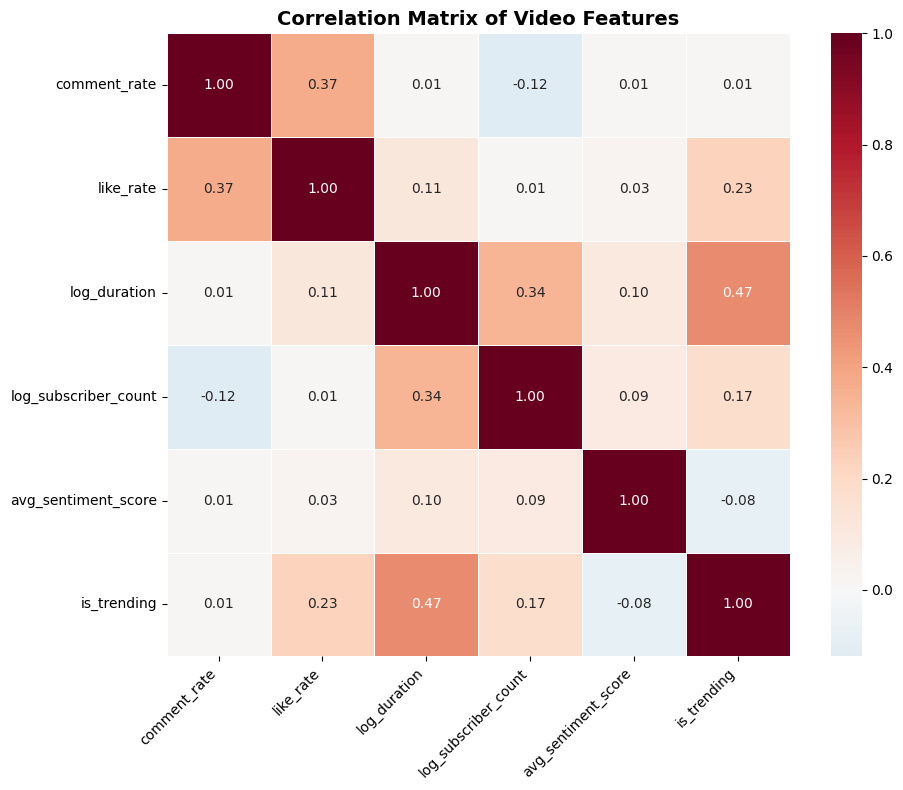

In [142]:
# Tạo các biến log
df_corr = df_video_unique.copy()

df_corr["log_view_count"] = np.log10(df_corr["view_count"] + 1)
df_corr["log_like_count"] = np.log10(df_corr["likes"] + 1)
df_corr["log_comment_count"] = np.log10(df_corr["comments"] + 1)
df_corr["log_subscriber_count"] = np.log10(df_corr["subscriber_count"] + 1)

# Chọn các biến phân tích
corr_cols = [
    "comment_rate",
    "like_rate",
    "log_duration",
    "log_subscriber_count",
    "avg_sentiment_score",
    "is_trending"
]

# Tính ma trận tương quan
corr_matrix = df_corr[corr_cols].corr()

# Vẽ heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Video Features",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

publish_weekday
Monday       19230
Tuesday      25132
Wednesday    24214
Thursday     26098
Friday       24022
Saturday     20071
Sunday       19214
Name: count, dtype: int64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22768\2647337881.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


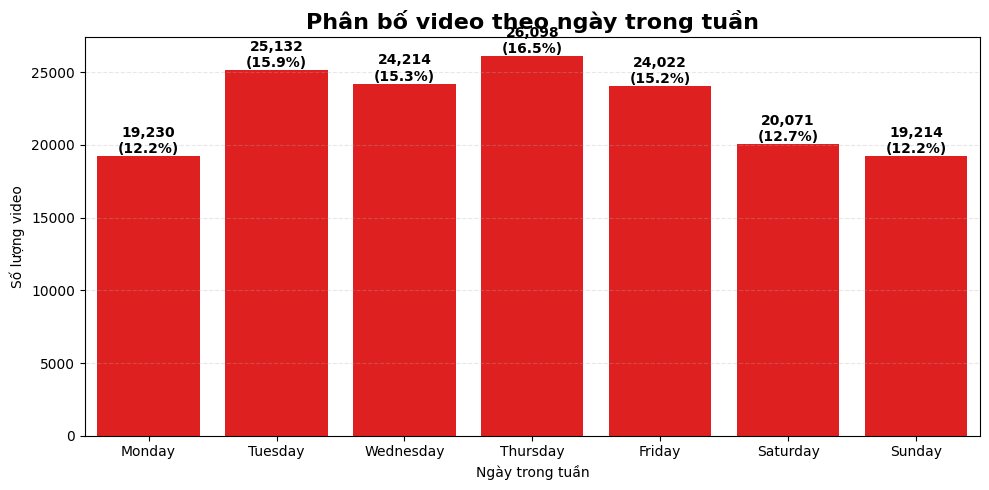

In [143]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thứ tự ngày trong tuần
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Đếm số lượng video theo ngày đăng
weekday_counts = (
    df_video["publish_weekday"]
    .value_counts()
    .reindex(weekday_order)
)

# Kiểm tra số liệu
print(weekday_counts)

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=weekday_counts.index,
    y=weekday_counts.values,
    palette=["#FF0000"] * len(weekday_counts)
)

total = weekday_counts.sum()

for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100

    ax.annotate(
        f"{count:,}\n({pct:.1f}%)",
        (
            p.get_x() + p.get_width()/2,
            p.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Phân bố video theo ngày trong tuần",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Ngày trong tuần")
plt.ylabel("Số lượng video")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()